# Load molecules

In [1]:
from chromatopy import ChromAnalyzer, Molecule, to_enzymeml
from pathlib import Path

molecules = []
molecule_dir = Path("result/calib_molecules")

for path in molecule_dir.glob("*.json"):
    molecule = Molecule.read_json(path)  # now with dedicated read method

    molecules.append(molecule)

print(f"Loaded {len(molecules)} molecules")

Loaded 4 molecules


# Load timecourse data

In [ ]:
timecourse_path = "data/time_sample/20241030 Ado ATP"

# need to define the initial concentrations of the molecules
# therefore create a dictionary with the molecule ids as key and the initial concentration as value
init_conc = {
    "Ado": 5,
    "ADP": 0,
    "AMP": 0,
    "ATP": 5,
}

# read the timecourse data
analyzer = ChromAnalyzer.read_agilent(
    path=timecourse_path, ph=8, temperature=37, mode="timecourse"
)

# add the calibration molecules to the timecourse data
for molecule in molecules:
    analyzer.add_molecule(
        molecule=molecule,
        init_conc=init_conc[molecule.id],
    )

analyzer.visualize_all(assigned_only=True)


# New to_enzymeml function, you can pass one or a list of analyzers
enzymeml_doc = to_enzymeml(
    document_name="My nice experiment with MjNK",
    analyzers=analyzer,
    calculate_concentration=True,
    extrapolate=False,
)

 Loaded 24 chromatograms.
🎯 Assigned Adenosine Triphosphate to 24 peaks
🎯 Assigned Adenosine Phosphate to 24 peaks
🎯 Assigned Adenosine-5'-diphosphate to 24 peaks
🎯 Assigned Adenosine to 24 peaks


# Visualize data

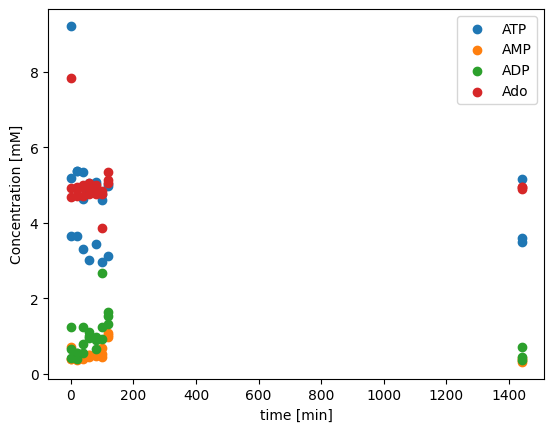

In [3]:
import matplotlib.pyplot as plt

for measurement in enzymeml_doc.measurements:
    for molecule in measurement.species_data:
        plt.scatter(molecule.time, molecule.data, label=molecule.species_id)
plt.xlabel("time [min]")
plt.ylabel("Concentration [mM]")
plt.legend()
plt.show()
